In [36]:
import torch
import torch.nn as nn
import math

# Transformer Architecture

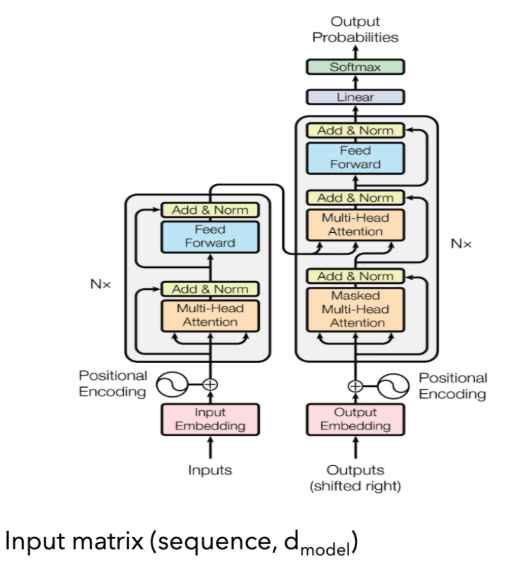

# 1. Input Embeddings

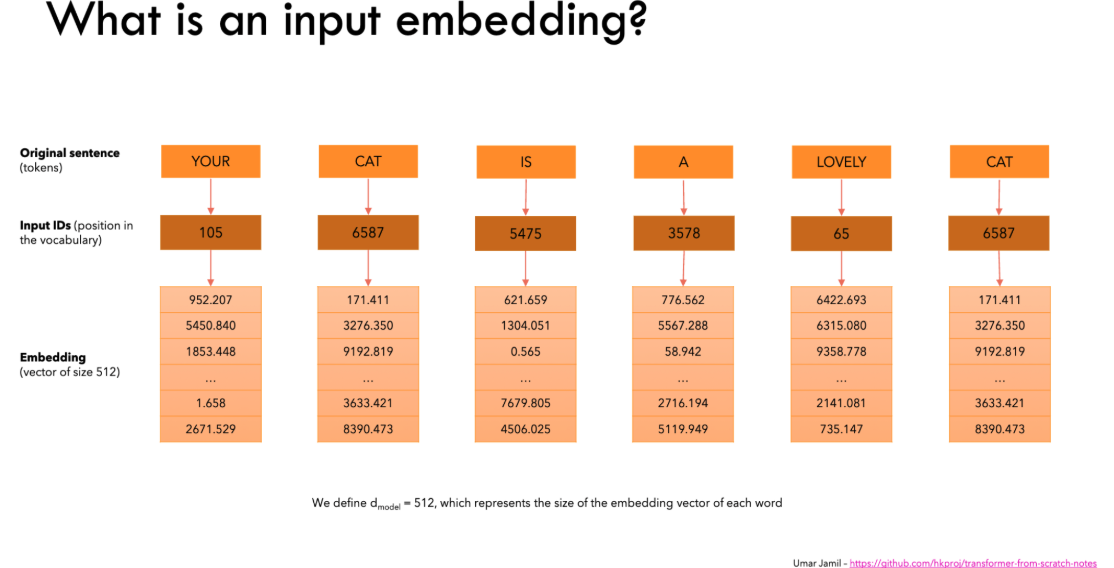

In [37]:
class InputEmbeddings(nn.Module):

    def __init__(self, d_model: int, vocab_size: int) -> None:
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x):
        # (batch, seq_len) --> (batch, seq_len, d_model)
        # Multiply by sqrt(d_model) to scale the embeddings according to the paper
        return self.embedding(x) * math.sqrt(self.d_model)

#### Initialization
- **Parameters**:
  - `d_model`: Embedding dimension (e.g., 512).
  - `vocab_size`: Number of unique tokens (e.g., 10,000 for English).
- **Components**:
  - `nn.Embedding(vocab_size, d_model)`: Creates a trainable lookup table of shape `(vocab_size, d_model)`.

#### Forward Pass
- **Input**: `x` with shape `(batch_size, seq_len)` (e.g., `(32, 350)`), token IDs from a tokenizer.
- **Process**:
  1. `self.embedding(x)`: Maps each token ID to a `d_model`-dimensional vector, yielding `(batch_size, seq_len, d_model)`.
  2. `* math.sqrt(self.d_model)`: Scales the embeddings by \(\sqrt{512} \approx 22.627\), preserving the shape.
- **Output**: `(batch_size, seq_len, d_model)` (e.g., `(32, 350, 512)`).

#### PyTorch Functions
- `nn.Embedding`: Lookup table for embeddings.
- `math.sqrt`: Scalar scaling factor.

#### Example
- Input: `[[0, 15, 3], [7, 22, 1]]` (shape `(2, 3)`).
- Output: Shape `(2, 3, 512)`, where each token is a 512D vector scaled by \(\sqrt{512}\).

# 2.Positional Encoding

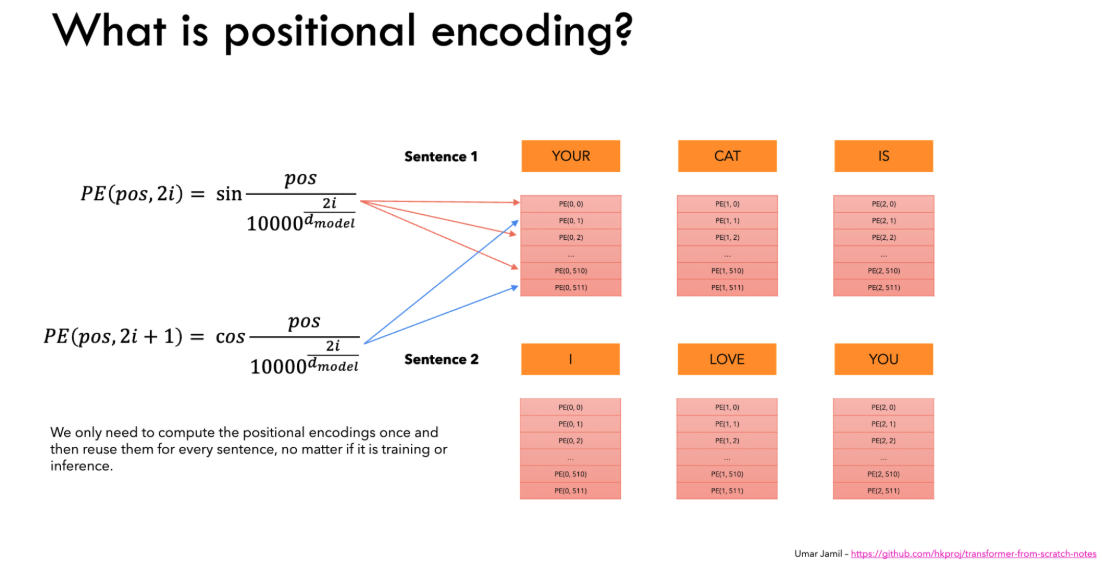

In [38]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model: int, seq_len: int, dropout: float) -> None:
        super().__init__()
        self.d_model = d_model
        self.seq_len = seq_len
        self.dropout = nn.Dropout(dropout)
        # Create a matrix of shape (seq_len, d_model)
        pe = torch.zeros(seq_len, d_model)
        # Create a vector of shape (seq_len)
        position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1) # (seq_len, 1)
        # Create a vector of shape (d_model)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)) # (d_model / 2)
        # Apply sine to even indices
        pe[:, 0::2] = torch.sin(position * div_term) # sin(position * (10000 ** (2i / d_model))
        # Apply cosine to odd indices
        pe[:, 1::2] = torch.cos(position * div_term) # cos(position * (10000 ** (2i / d_model))
        # Add a batch dimension to the positional encoding
        pe = pe.unsqueeze(0) # (1, seq_len, d_model)
        # Register the positional encoding as a buffer
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + (self.pe[:, :x.shape[1], :]).requires_grad_(False) # (batch, seq_len, d_model)
        return self.dropout(x)

#### Initialization
- **Parameters**:
  - `d_model`: Embedding dimension (e.g., 512).
  - `seq_len`: Maximum sequence length (e.g., 350).
  - `dropout`: Dropout rate (e.g., 0.1).
- **Steps**:
  1. `pe = torch.zeros(seq_len, d_model)`: Initializes a `(350, 512)` tensor.
  2. `position = torch.arange(...).unsqueeze(1)`: Creates `(350, 1)` position indices.
  3. `div_term = torch.exp(...)`: Computes `(256,)` divisor terms.
  4. Sine/Cosine: Fills `pe` with periodic functions.
  5. `pe.unsqueeze(0)`: Expands to `(1, 350, 512)`.
  6. `self.register_buffer('pe', pe)`: Registers as a non-trainable buffer.

#### Forward Pass
- **Input**: `x` with shape `(batch_size, seq_len, d_model)` (e.g., `(32, 350, 512)`).
- **Process**:
  1. Adds `self.pe[:, :x.shape[1], :]` (e.g., `(1, 350, 512)`), sliced to match input length.
  2. Applies `self.dropout(x)` for regularization.
- **Output**: `(batch_size, seq_len, d_model)`.

#### PyTorch Functions
- `torch.zeros`: Initializes the encoding matrix.
- `torch.arange`: Generates position indices.
- `torch.exp`, `torch.sin`, `torch.cos`: Compute positional encodings.
- `nn.Dropout`: Adds regularization.
- `register_buffer`: Stores `pe` as a buffer.

#### Example
- Input: `(2, 3, 512)` (2 sequences, 3 tokens, 512D).
- Output: `(2, 3, 512)` with positional encodings added.

# 3. Layer Normalization

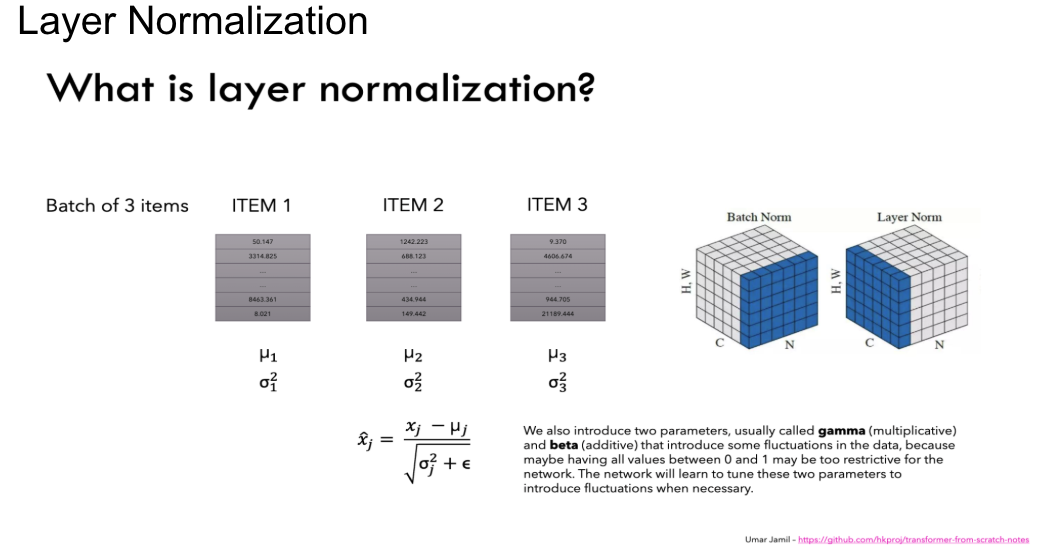

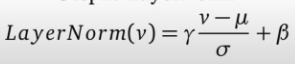

In [39]:

class LayerNormalization(nn.Module):

    def __init__(self, features: int, eps:float=10**-6) -> None:
        super().__init__()
        self.eps = eps
        self.alpha = nn.Parameter(torch.ones(features)) # alpha is a learnable parameter
        self.bias = nn.Parameter(torch.zeros(features)) # bias is a learnable parameter

    def forward(self, x):
        # x: (batch, seq_len, hidden_size)
         # Keep the dimension for broadcasting
        mean = x.mean(dim = -1, keepdim = True) # (batch, seq_len, 1)
        # Keep the dimension for broadcasting
        std = x.std(dim = -1, keepdim = True) # (batch, seq_len, 1)
        # eps is to prevent dividing by zero or when std is very small
        return self.alpha * (x - mean) / (std + self.eps) + self.bias


### Layer Normalization Layer

The `LayerNormalization` class normalizes inputs across the feature dimension, stabilizing training in the Transformer. It’s used in residual connections within encoder and decoder blocks.

#### Purpose
- Normalizes token embeddings across `hidden_size` (e.g., `d_model=512`).
- Improves gradient flow and training stability with learnable scaling and shifting.

#### Key Concepts
- **Input Shape**: `(batch_size, seq_len, hidden_size)` - Sub-layer outputs.
- **Output Shape**: `(batch_size, seq_len, hidden_size)` - Normalized outputs.
- **Formula**: \( \text{output} = \alpha \cdot \frac{x - \mu}{\sigma + \epsilon} + \text{bias} \).

In [40]:
# Example usage
features = 512
batch_size = 2
seq_len = 3

layer_norm = LayerNormalization(features)
x = torch.randn(batch_size, seq_len, features)  # Shape: (2, 3, 512)
output = layer_norm(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

Input shape: torch.Size([2, 3, 512])
Output shape: torch.Size([2, 3, 512])


# 4. Feed Forward Block

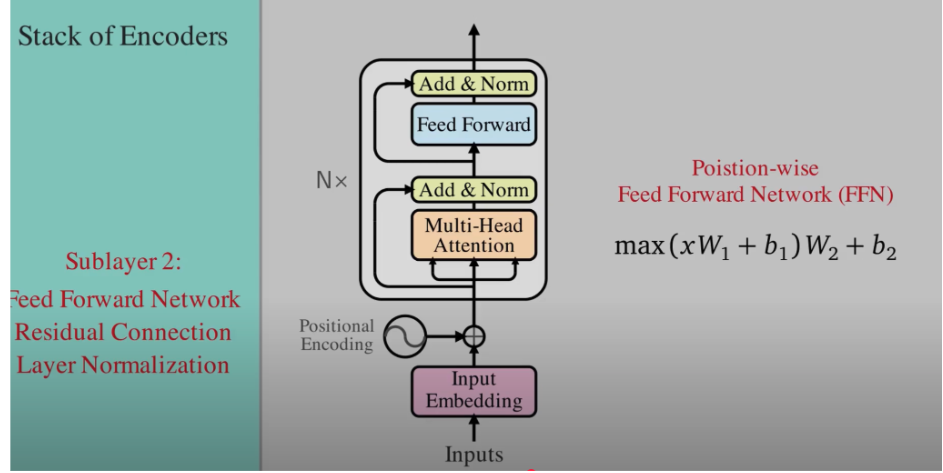

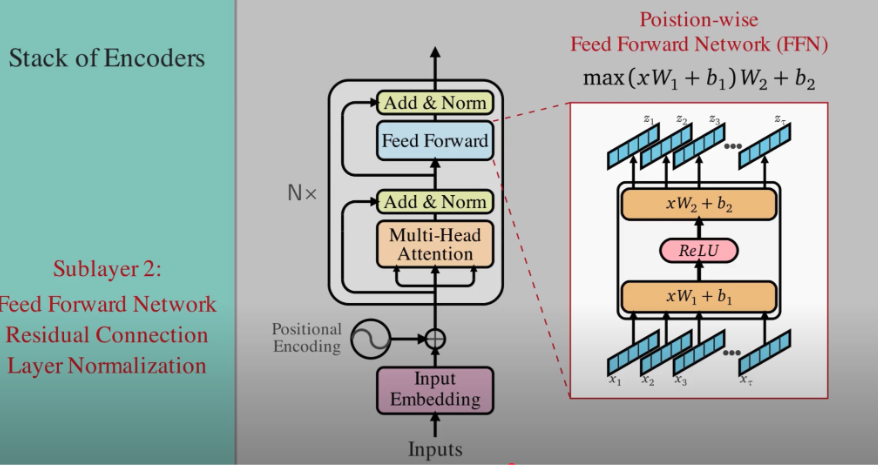

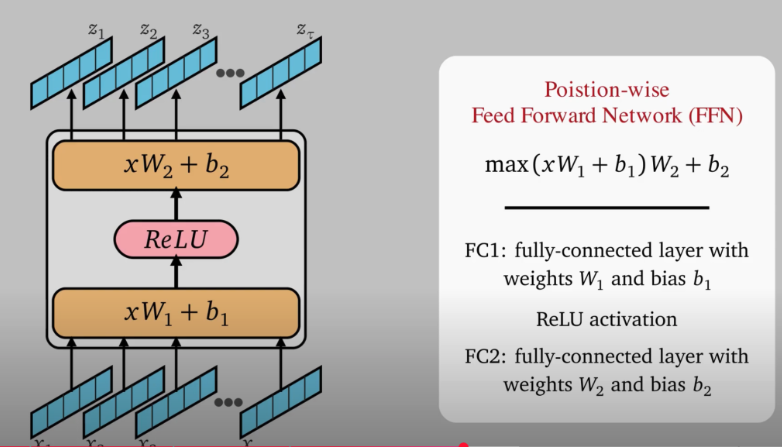

In [41]:
class FeedForwardBlock(nn.Module):

    def __init__(self, d_model: int, d_ff: int, dropout: float) -> None:
        super().__init__()
        self.linear_1 = nn.Linear(d_model, d_ff) # w1 and b1
        self.dropout = nn.Dropout(dropout)
        self.linear_2 = nn.Linear(d_ff, d_model) # w2 and b2

    def forward(self, x):
        # (batch, seq_len, d_model) --> (batch, seq_len, d_ff) --> (batch, seq_len, d_model)
        return self.linear_2(self.dropout(torch.relu(self.linear_1(x))))

#### Key Concepts
- **Input Shape**: `(batch_size, seq_len, d_model)` - From previous layer.
- **Output Shape**: `(batch_size, seq_len, d_model)` - Transformed embeddings.
- **Structure**: Linear → ReLU → Dropout → Linear.

#### Initialization
- **Parameters**:
  - `d_model`: Input/output dimension (e.g., 512).
  - `d_ff`: Hidden layer size (e.g., 2048).
  - `dropout`: Dropout rate (e.g., 0.1).
- **Components**:
  - `self.linear_1`: Maps `d_model` to `d_ff`.
  - `self.dropout`: Regularizes the hidden layer.
  - `self.linear_2`: Maps `d_ff` back to `d_model`.

#### Forward Pass
- **Input**: `x` with shape `(batch_size, seq_len, d_model)` (e.g., `(32, 350, 512)`).
- **Process**:
  1. `self.linear_1(x)`: Shape `(32, 350, 2048)`.
  2. `torch.relu(...)`: Adds non-linearity, shape `(32, 350, 2048)`.
  3. `self.dropout(...)`: Applies dropout, shape `(32, 350, 2048)`.
  4. `self.linear_2(...)`: Shape `(32, 350, 512)`.
- **Output**: `(batch_size, seq_len, d_model)`.

#### PyTorch Functions
- `nn.Linear`: Linear transformations.
- `torch.relu`: ReLU activation.
- `nn.Dropout`: Dropout regularization.

#### Example
- Input: `(1, 2, 2)` tensor `[[[1., 2.], [3., 4.]]]`.
- Output: `(1, 2, 2)` after expansion to `d_ff` and contraction.

In [42]:
# Example usage
d_model = 512
d_ff = 2048
dropout = 0.1
batch_size = 2
seq_len = 3

ff_block = FeedForwardBlock(d_model, d_ff, dropout)
x = torch.randn(batch_size, seq_len, d_model)  # Shape: (2, 3, 512)
output = ff_block(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

Input shape: torch.Size([2, 3, 512])
Output shape: torch.Size([2, 3, 512])


# 5. Multi-Head Attention

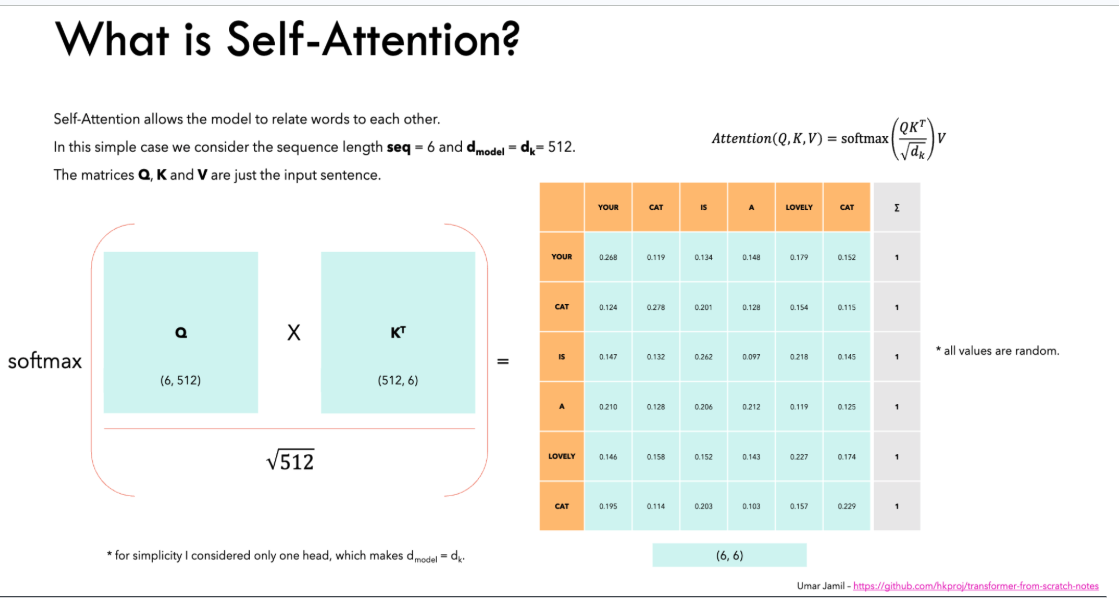

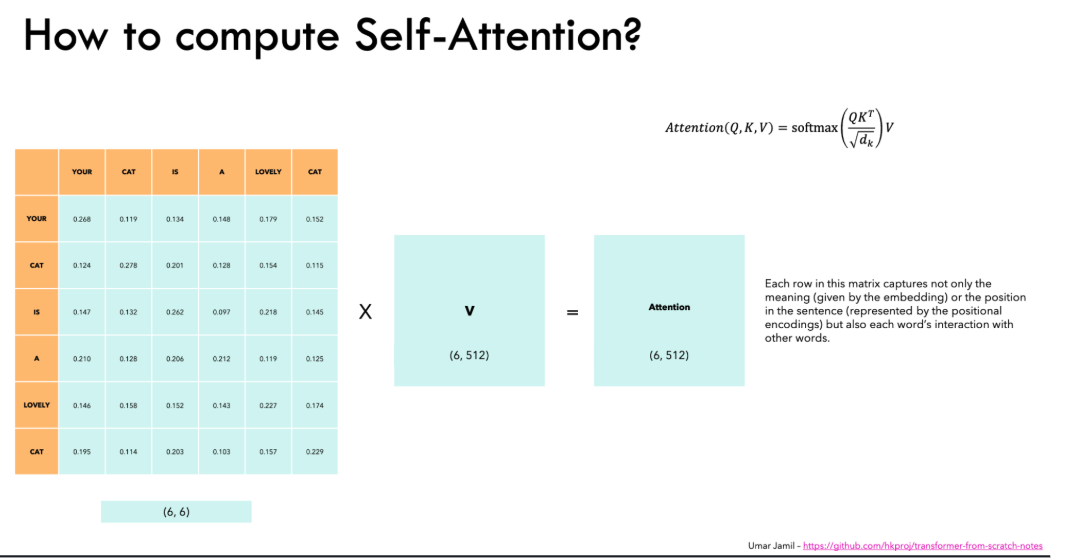

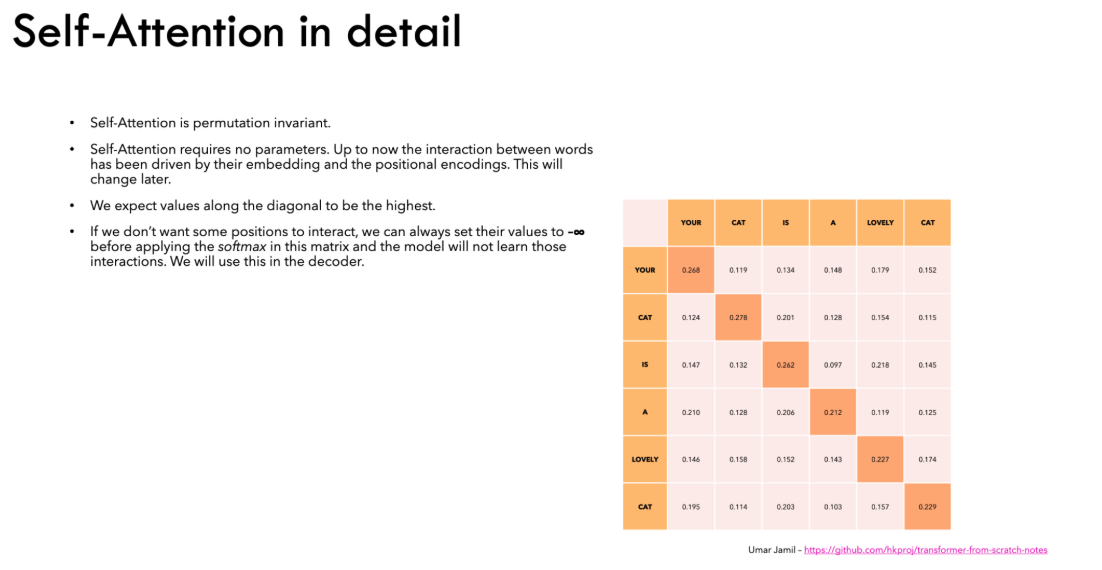

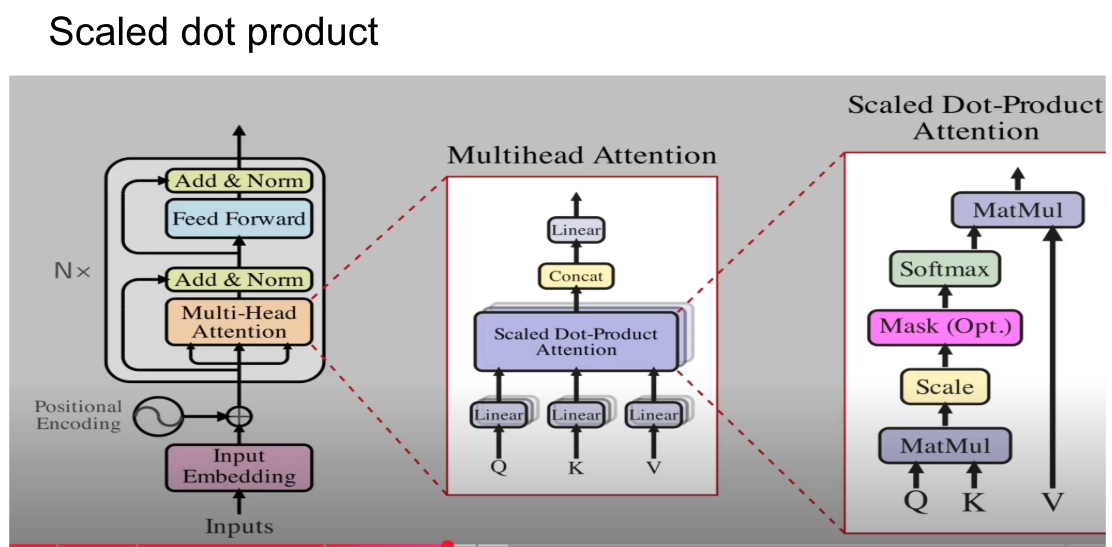

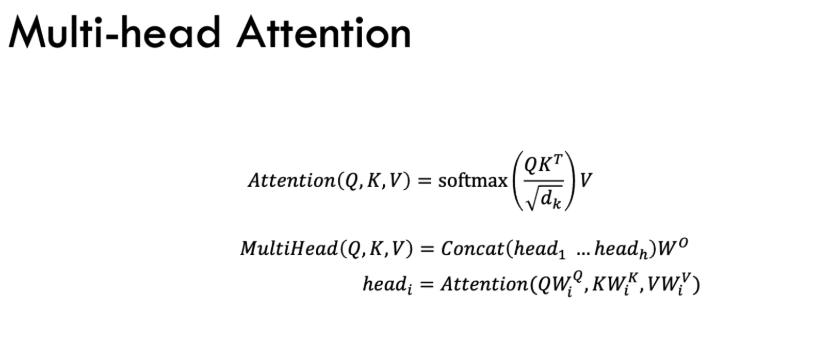

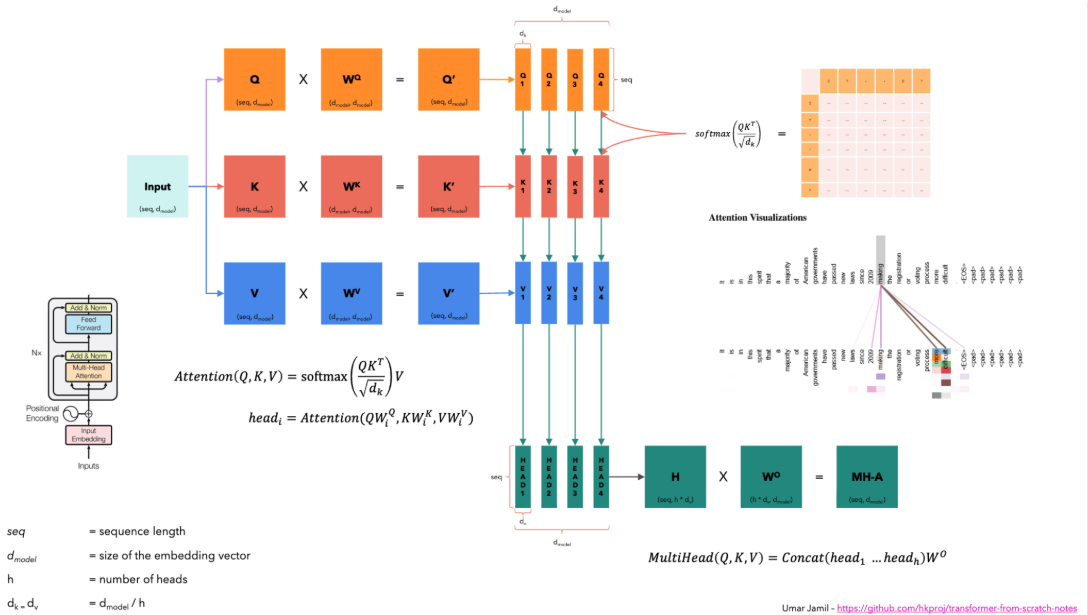

In [43]:
class MultiHeadAttentionBlock(nn.Module):

    def __init__(self, d_model: int, h: int, dropout: float) -> None:
        super().__init__()
        self.d_model = d_model # Embedding vector size
        self.h = h # Number of heads
        # Make sure d_model is divisible by h
        assert d_model % h == 0, "d_model is not divisible by h"

        self.d_k = d_model // h # Dimension of vector seen by each head
        self.w_q = nn.Linear(d_model, d_model, bias=False) # Wq
        self.w_k = nn.Linear(d_model, d_model, bias=False) # Wk
        self.w_v = nn.Linear(d_model, d_model, bias=False) # Wv
        self.w_o = nn.Linear(d_model, d_model, bias=False) # Wo
        self.dropout = nn.Dropout(dropout)

    @staticmethod
    def attention(query, key, value, mask, dropout: nn.Dropout):
        d_k = query.shape[-1]
        # Just apply the formula from the paper
        # (batch, h, seq_len, d_k) --> (batch, h, seq_len, seq_len)
        attention_scores = (query @ key.transpose(-2, -1)) / math.sqrt(d_k)
        if mask is not None:
            # Write a very low value (indicating -inf) to the positions where mask == 0
            attention_scores.masked_fill_(mask == 0, -1e9)
        attention_scores = attention_scores.softmax(dim=-1) # (batch, h, seq_len, seq_len) # Apply softmax
        if dropout is not None:
            attention_scores = dropout(attention_scores)
        # (batch, h, seq_len, seq_len) --> (batch, h, seq_len, d_k)
        # return attention scores which can be used for visualization
        return (attention_scores @ value), attention_scores

    def forward(self, q, k, v, mask):
        query = self.w_q(q) # (batch, seq_len, d_model) --> (batch, seq_len, d_model)
        key = self.w_k(k) # (batch, seq_len, d_model) --> (batch, seq_len, d_model)
        value = self.w_v(v) # (batch, seq_len, d_model) --> (batch, seq_len, d_model)

        # (batch, seq_len, d_model) --> (batch, seq_len, h, d_k) --> (batch, h, seq_len, d_k)
        query = query.view(query.shape[0], query.shape[1], self.h, self.d_k).transpose(1, 2)
        key = key.view(key.shape[0], key.shape[1], self.h, self.d_k).transpose(1, 2)
        value = value.view(value.shape[0], value.shape[1], self.h, self.d_k).transpose(1, 2)

        # Calculate attention
        x, self.attention_scores = MultiHeadAttentionBlock.attention(query, key, value, mask, self.dropout)
        
        # Combine all the heads together
        # (batch, h, seq_len, d_k) --> (batch, seq_len, h, d_k) --> (batch, seq_len, d_model)
        x = x.transpose(1, 2).contiguous().view(x.shape[0], -1, self.h * self.d_k)

        # Multiply by Wo
        # (batch, seq_len, d_model) --> (batch, seq_len, d_model)  
        return self.w_o(x)

### Initialization (`__init__`)

#### Parameters:
- **d_model** (`int`): Embedding dimension (e.g., 512), the size of each token’s vector.
- **h** (`int`): Number of attention heads (e.g., 8).
- **dropout** (`float`): Dropout rate (e.g., 0.1) for regularization.

#### Attributes:
- `self.d_model`: Embedding size.
- `self.h`: Number of heads.
- `self.d_k`: Dimension per head, calculated as `d_model // h` (e.g., `512 // 8 = 64`).

#### Linear Layers:
- `self.w_q`, `self.w_k`, `self.w_v`: Linear transformations for **query**, **key**, and **value** projections.
- `self.w_o`: Linear transformation to **combine head outputs**.
- `self.dropout`: Dropout layer.

#### PyTorch Components:
- `assert d_model % h == 0`: Ensures `d_model` is divisible by `h`.
- `nn.Linear(d_model, d_model, bias=False)`: Defines projections **without bias**.
- `nn.Dropout(dropout)`: Applies dropout for **regularization**.

---

### Static Method: `attention`

#### **Purpose**
Computes **scaled dot-product attention**, the core operation of the mechanism.

#### **Inputs**
- `query`, `key`, `value`: Tensors of shape **(batch, h, seq_len, d_k)**.
- `mask`: Optional tensor to **mask positions** (e.g., padding or future tokens).
- `dropout`: Dropout layer for attention weights.

#### **Process**
##### 1. Compute Attention Scores:
\[
\text{attention\_scores} = \frac{Q \cdot K^T}{\sqrt{d_k}}
\]
- **Operation**: `query @ key.transpose(-2, -1)` performs the **dot product**, scaled by `math.sqrt(d_k)` to stabilize gradients.
- **Shape**: `(batch, h, seq_len, seq_len)`.

##### 2. Apply Mask (if provided):
```python
attention_scores.masked_fill_(mask == 0, -1e9)


In [44]:
# Example usage
d_model = 512
h = 8
dropout = 0.1
batch_size = 2
seq_len = 3

# Initialize the attention block
attention_block = MultiHeadAttentionBlock(d_model, h, dropout)

# Create sample input tensors
q = torch.randn(batch_size, seq_len, d_model)
k = torch.randn(batch_size, seq_len, d_model)
v = torch.randn(batch_size, seq_len, d_model)
mask = None  # Could be a tensor like torch.ones(batch_size, h, seq_len, seq_len)

# Forward pass
output = attention_block(q, k, v, mask)

# Check shapes
print(f"Input shape: {q.shape}")      # Expected: torch.Size([2, 3, 512])
print(f"Output shape: {output.shape}") # Expected: torch.Size([2, 3, 512])

Input shape: torch.Size([2, 3, 512])
Output shape: torch.Size([2, 3, 512])


# 6. Add & Norm (Residual Connection)

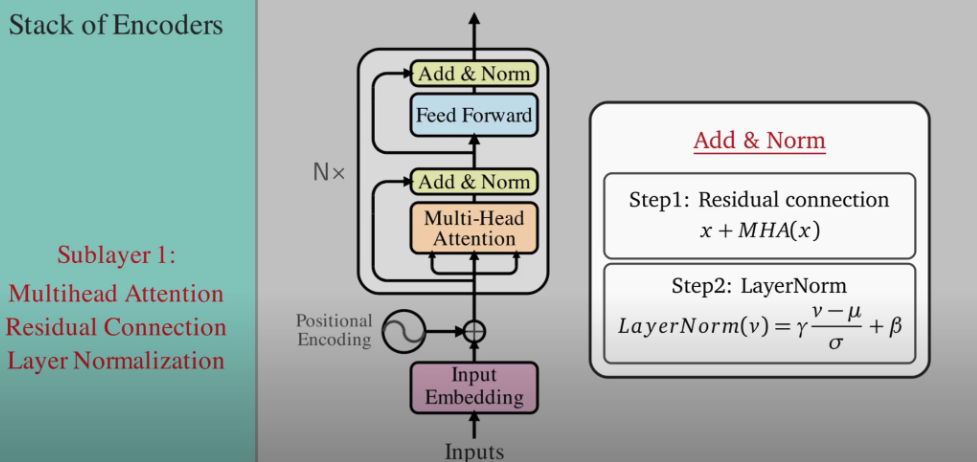

In [45]:
class ResidualConnection(nn.Module):
    
        def __init__(self, features: int, dropout: float) -> None:
            super().__init__()
            self.dropout = nn.Dropout(dropout)
            self.norm = LayerNormalization(features)
    
        def forward(self, x, sublayer):
            return x + self.dropout(sublayer(self.norm(x)))

# Encoder

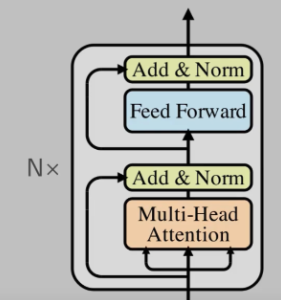

In [46]:
class EncoderBlock(nn.Module):

    def __init__(self, features: int, 
                 self_attention_block: MultiHeadAttentionBlock, 
                 feed_forward_block: FeedForwardBlock, 
                 dropout: float) -> None:
        
        super().__init__()
        self.self_attention_block = self_attention_block
        self.feed_forward_block = feed_forward_block
        self.residual_connections = nn.ModuleList([ResidualConnection(features, dropout) for _ in range(2)])

    def forward(self, x, src_mask):
        x = self.residual_connections[0](x, lambda x: self.self_attention_block(x, x, x, src_mask)) 
        x = self.residual_connections[1](x, self.feed_forward_block)
        return x
    
class Encoder(nn.Module):

    def __init__(self, features: int, layers: nn.ModuleList) -> None:
        super().__init__()
        self.layers = layers
        self.norm = LayerNormalization(features)

    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

# Decoder

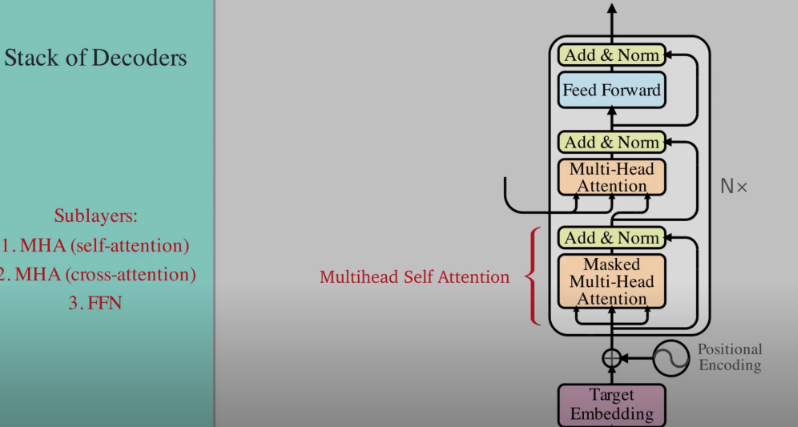

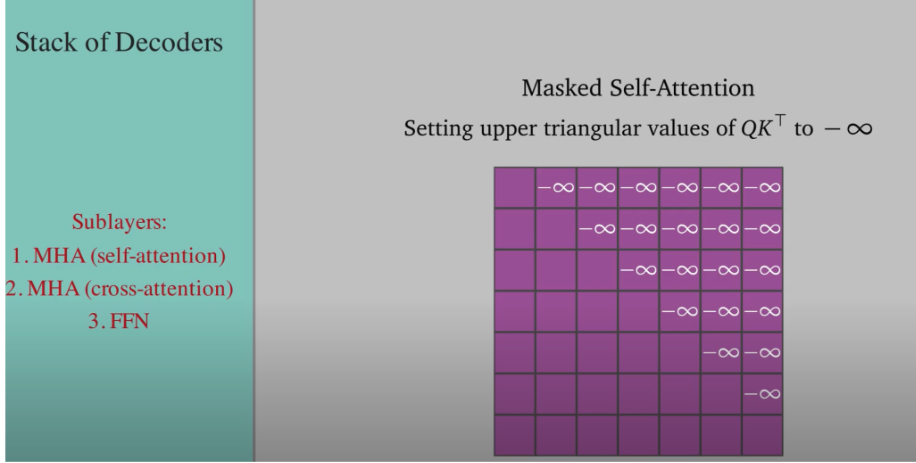

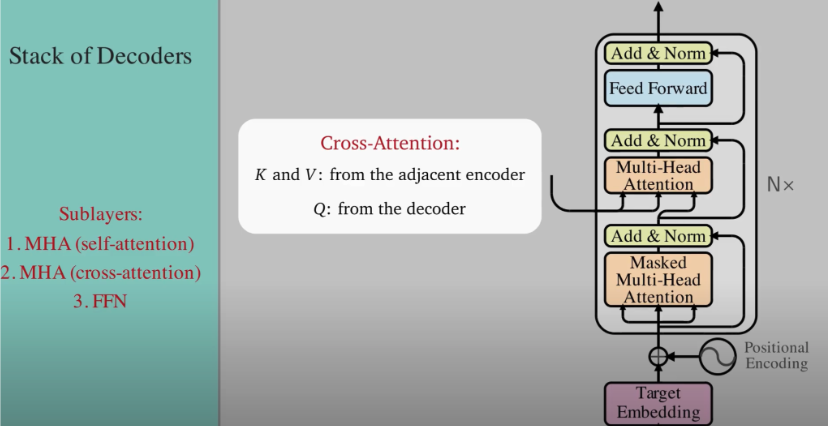

In [47]:
class DecoderBlock(nn.Module):

    def __init__(self, features: int, 
                 self_attention_block: MultiHeadAttentionBlock, 
                 cross_attention_block: MultiHeadAttentionBlock, 
                 feed_forward_block: FeedForwardBlock, dropout: float) -> None:
        
        super().__init__()
        self.self_attention_block = self_attention_block
        self.cross_attention_block = cross_attention_block
        self.feed_forward_block = feed_forward_block
        self.residual_connections = nn.ModuleList([ResidualConnection(features, dropout) for _ in range(3)])

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        x = self.residual_connections[0](x, lambda x: self.self_attention_block(x, x, x, tgt_mask))
        x = self.residual_connections[1](x, lambda x: self.cross_attention_block(x, encoder_output, encoder_output, src_mask)) #cross-attention
        x = self.residual_connections[2](x, self.feed_forward_block)
        return x
    
class Decoder(nn.Module):

    def __init__(self, features: int, layers: nn.ModuleList) -> None:
        super().__init__()
        self.layers = layers
        self.norm = LayerNormalization(features)

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)
        return self.norm(x)

# Projection Layer

In [48]:
class ProjectionLayer(nn.Module):

    def __init__(self, d_model, vocab_size) -> None:
        super().__init__()
        self.proj = nn.Linear(d_model, vocab_size)

    def forward(self, x) -> None:
        # (batch, seq_len, d_model) --> (batch, seq_len, vocab_size)
        return self.proj(x)

# Transformer

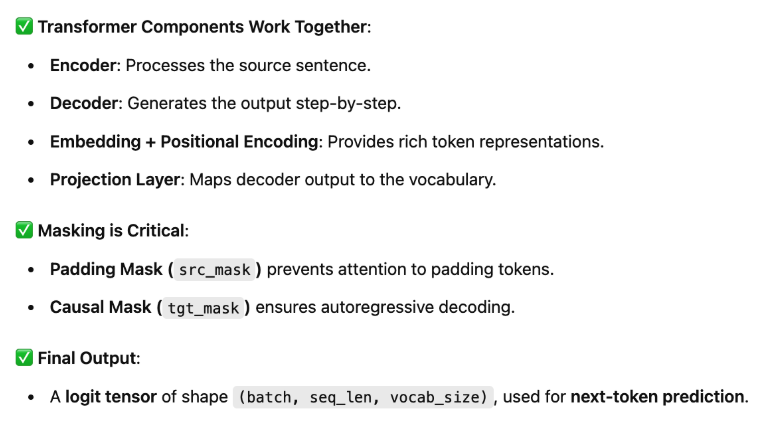

In [49]:
class Transformer(nn.Module):

    def __init__(self, encoder: Encoder, 
                 decoder: Decoder, 
                 src_embed: InputEmbeddings, 
                 tgt_embed: InputEmbeddings, 
                 src_pos: PositionalEncoding, 
                 tgt_pos: PositionalEncoding, 
                 projection_layer: ProjectionLayer) -> None:
        
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.src_pos = src_pos
        self.tgt_pos = tgt_pos
        self.projection_layer = projection_layer

    def encode(self, src, src_mask):
        # (batch, seq_len, d_model)
        src = self.src_embed(src)
        src = self.src_pos(src)
        return self.encoder(src, src_mask)
    
    def decode(self, encoder_output: torch.Tensor, src_mask: torch.Tensor, tgt: torch.Tensor, tgt_mask: torch.Tensor):
        # (batch, seq_len, d_model)
        tgt = self.tgt_embed(tgt)
        tgt = self.tgt_pos(tgt)
        return self.decoder(tgt, encoder_output, src_mask, tgt_mask)
    
    def project(self, x):
        # (batch, seq_len, vocab_size)
        return self.projection_layer(x)

In [50]:
def build_transformer(src_vocab_size: int, 
                      tgt_vocab_size: int,
                        src_seq_len: int, 
                        tgt_seq_len: int, 
                        d_model: int=512, 
                        N: int=6, h: int=8, 
                        dropout: float=0.1, 
                        d_ff: int=2048) -> Transformer:
    
    # Create the embedding layers
    src_embed = InputEmbeddings(d_model, src_vocab_size)
    tgt_embed = InputEmbeddings(d_model, tgt_vocab_size)

    # Create the positional encoding layers
    src_pos = PositionalEncoding(d_model, src_seq_len, dropout)
    tgt_pos = PositionalEncoding(d_model, tgt_seq_len, dropout)
    
    # Create the encoder blocks
    encoder_blocks = []
    for _ in range(N):
        encoder_self_attention_block = MultiHeadAttentionBlock(d_model, h, dropout)
        feed_forward_block = FeedForwardBlock(d_model, d_ff, dropout)
        encoder_block = EncoderBlock(d_model, encoder_self_attention_block, feed_forward_block, dropout)
        encoder_blocks.append(encoder_block)

    # Create the decoder blocks
    decoder_blocks = []
    for _ in range(N):
        decoder_self_attention_block = MultiHeadAttentionBlock(d_model, h, dropout)
        decoder_cross_attention_block = MultiHeadAttentionBlock(d_model, h, dropout)
        feed_forward_block = FeedForwardBlock(d_model, d_ff, dropout)
        decoder_block = DecoderBlock(d_model, decoder_self_attention_block, 
                                     decoder_cross_attention_block, 
                                     feed_forward_block, 
                                     dropout)
        decoder_blocks.append(decoder_block)
    
    # Create the encoder and decoder
    encoder = Encoder(d_model, nn.ModuleList(encoder_blocks))
    decoder = Decoder(d_model, nn.ModuleList(decoder_blocks))
    
    # Create the projection layer
    projection_layer = ProjectionLayer(d_model, tgt_vocab_size)
    
    # Create the transformer
    transformer = Transformer(encoder, 
                              decoder, 
                              src_embed, 
                              tgt_embed,
                              src_pos, 
                              tgt_pos, 
                              projection_layer)
    
    # Initialize the parameters
    for p in transformer.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    
    return transformer